In [62]:
#Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, hinge_loss, log_loss
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [63]:
#Loading the datasets
df1 = pd.read_csv('DiaBD A Diabetes Dataset for Enhanced Risk Analysis\DiaBD_A Diabetes Dataset for Enhanced Risk Analysis and Research in Bangladesh.csv')      # DiaBD dataset
df2 = pd.read_csv('DiaBD A Diabetes Dataset for Enhanced Risk Analysis\Type2_Diabetes_Dataset.csv')      # Clinical dataset

# DiaBD
df1 = df1.rename(columns={
    'age': 'Age',
    'bmi': 'BMI',
    'systolic_bp': 'BP_systolic',
    'diastolic_bp': 'BP_diastolic',
    'glucose': 'Glucose',
    'diabetic': 'Outcome'
})

# Type-2 Clinical dataset
df2 = df2.rename(columns={
    'No. of Pregnancy': 'Pregnancies',
    'Age': 'Age',
    'BMI': 'BMI',
    'BP(Systolic)': 'BP_systolic',
    'BP(Diastolic)': 'BP_diastolic',
    'DiabetesPedigreeFunction': 'DiabetesPedigreeFunction',
    'Insulin': 'Insulin',
    'Skin Thickness(mm)': 'SkinThickness',
    'Glucose': 'Glucose',
    'Outcome': 'Outcome'
})

# Mapping the 'Outcome' column to binary values
df1['Outcome'] = df1['Outcome'].map({'Yes': 1, 'No': 0})
df2['Outcome'] = df2['Outcome'].map({1: 1, 0: 0})

# Handling missing values in df1 by filling them with random values within a reasonable range
df1['Pregnancies'] = np.random.randint(1, 9, size=len(df1))
df1['Insulin'] = np.random.uniform(1, 14, size=len(df1))
df1['SkinThickness'] = np.random.uniform(10, 50, size=len(df1))
df1['DiabetesPedigreeFunction'] = np.random.uniform(0.1, 2.5, size=len(df1))

# Reordering columns in df1 to match df2
df1 = df1[[
    'Pregnancies', 'Age', 'BMI',
    'BP_systolic', 'BP_diastolic',
    'DiabetesPedigreeFunction',
    'Insulin', 'SkinThickness',
    'Glucose', 'Outcome'
]]

# Reorder columns in df2 to match df1, selecting only columns that exist
df2 = df2[[
    'Pregnancies', 'Age', 'BMI',
    'BP_systolic', 'BP_diastolic',
    'DiabetesPedigreeFunction',
    'Insulin', 'SkinThickness',
    'Glucose', 'Outcome'
]]


In [64]:
# Handling missing values in df1 and df2 by replacing 0 with NaN for specific columns
cols = ['BMI', 'BP_systolic', 'BP_diastolic', 'Insulin', 'SkinThickness', 'Glucose']

for col in cols:
    df1[col] = df1[col].replace(0, np.nan)
    df2[col] = df2[col].replace(0, np.nan)

# Filling missing values with median for both datasets
for col in cols:
    df1[col].fillna(df1[col].median(), inplace=True)
    df2[col].fillna(df2[col].median(), inplace=True)

df1['DiabetesPedigreeFunction'].fillna(0.5, inplace=True)
df2['DiabetesPedigreeFunction'].fillna(df2['DiabetesPedigreeFunction'].median(), inplace=True)


0      0
1      2
2      0
3      0
4      0
      ..
460    2
461    0
462    0
463    0
464    2
Name: DiabetesPedigreeFunction, Length: 465, dtype: int64

In [65]:
# Displaying information about the datasets
df1.info()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 5288 entries, 0 to 5287
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               5288 non-null   int32  
 1   Age                       5288 non-null   int64  
 2   BMI                       5288 non-null   float64
 3   BP_systolic               5288 non-null   int64  
 4   BP_diastolic              5288 non-null   int64  
 5   DiabetesPedigreeFunction  5288 non-null   float64
 6   Insulin                   5288 non-null   float64
 7   SkinThickness             5288 non-null   float64
 8   Glucose                   5287 non-null   float64
 9   Outcome                   5288 non-null   int64  
dtypes: float64(5), int32(1), int64(4)
memory usage: 392.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --

In [66]:
# Merging the datasets
merged_df = pd.concat([df1, df2], ignore_index=True)

# Handling missing values in the merged dataset by filling them with median values
merged_df['Glucose'].fillna(merged_df['Glucose'].median(), inplace=True)
merged_df['Insulin'].fillna(merged_df['Insulin'].median(), inplace=True)
merged_df['SkinThickness'].fillna(merged_df['SkinThickness'].median(), inplace=True)

# Removing duplicates and resetting index
merged_df.drop_duplicates(inplace=True)
merged_df.reset_index(drop=True, inplace=True)

merged_df['Glucose'] = merged_df['Glucose'].round()
merged_df['Insulin'] = merged_df['Insulin'].round()
merged_df['SkinThickness'] = merged_df['SkinThickness'].round()

merged_df['Glucose'] = merged_df['Glucose'].fillna(merged_df['Glucose'].median()).astype('int64')
merged_df['Insulin'] = merged_df['Insulin'].fillna(merged_df['Insulin'].median()).astype('int64')
merged_df['SkinThickness'] = merged_df['SkinThickness'].fillna(merged_df['SkinThickness'].median()).astype('int64')

# Saving the merged dataset to a new CSV file
merged_df.to_csv("final_diabetes_dataset.csv", index=False)

In [67]:
merged_df.info()
merged_df['Outcome'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 5752 entries, 0 to 5751
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               5752 non-null   int64  
 1   Age                       5752 non-null   int64  
 2   BMI                       5752 non-null   float64
 3   BP_systolic               5752 non-null   int64  
 4   BP_diastolic              5752 non-null   int64  
 5   DiabetesPedigreeFunction  5752 non-null   float64
 6   Insulin                   5752 non-null   int64  
 7   SkinThickness             5752 non-null   int64  
 8   Glucose                   5752 non-null   int64  
 9   Outcome                   5752 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 449.5 KB


Outcome
0    5038
1     714
Name: count, dtype: int64

In [68]:
# Separating the majority and minority classes
df_majority = merged_df[merged_df['Outcome'] == 0]
df_minority = merged_df[merged_df['Outcome'] == 1]

# Downsampling the majority class to some extent to balance the dataset
df_majority_downsampled = df_majority.sample(
    n=1931,
    random_state=42
)

# Combining the downsampled majority class with the minority class
balanced_df = pd.concat([df_majority_downsampled, df_minority])
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Checking the class distribution in the balanced dataset
print(balanced_df['Outcome'].value_counts())

# percentage check
counts = balanced_df['Outcome'].value_counts(normalize=True) * 100
print(counts)


Outcome
0    1931
1     714
Name: count, dtype: int64
Outcome
0    73.005671
1    26.994329
Name: proportion, dtype: float64


In [69]:
# Saving the balanced dataset & updating the final dataset with the balanced data
merged_df = balanced_df.copy()
merged_df.to_csv("final_diabetes_dataset.csv", index=False)

In [70]:
# Loading the final dataset and checking the class distribution
final_df = pd.read_csv("final_diabetes_dataset.csv")
final_df['Outcome'].value_counts()

Outcome
0    1931
1     714
Name: count, dtype: int64

In [71]:
final_df.head()

,Pregnancies,Age,BMI,BP_systolic,BP_diastolic,DiabetesPedigreeFunction,Insulin,SkinThickness,Glucose,Outcome
0,2,25,16.790000,111,73,2.157546,11,17,6,0
1,2,37,23.822169,90,60,1.000000,8,356,100,1
2,8,52,24.340000,152,100,0.682393,10,37,15,0
3,7,40,31.430000,141,79,2.084970,4,15,10,0
4,1,40,22.060000,173,107,0.235209,8,23,7,0


In [72]:
final_df.shape

(2645, 10)

In [73]:
final_df.describe()

,Pregnancies,Age,BMI,BP_systolic,BP_diastolic,DiabetesPedigreeFunction,Insulin,SkinThickness,Glucose,Outcome
count,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000,2645.000000
mean,4.277127,45.797732,22.900281,132.705860,82.218904,1.326271,8.006049,72.514556,29.318336,0.269943
std,2.292514,13.158305,4.137895,22.089088,12.263593,0.920764,4.396047,101.590604,56.321169,0.444014
min,0.000000,21.000000,13.310000,62.000000,30.000000,0.000000,1.000000,10.000000,0.000000,0.000000
25%,2.000000,35.000000,20.190000,119.000000,74.000000,0.634444,5.000000,22.000000,6.000000,0.000000
50%,4.000000,45.000000,22.390000,129.000000,80.000000,1.232583,8.000000,34.000000,7.000000,0.000000
75%,6.000000,55.000000,25.150000,145.000000,90.000000,1.980020,11.000000,46.000000,11.000000,1.000000
max,12.000000,86.000000,47.970000,231.000000,120.000000,8.000000,44.000000,406.000000,450.000000,1.000000


In [74]:
final_df.groupby('Outcome').mean()

,Pregnancies,Age,BMI,BP_systolic,BP_diastolic,DiabetesPedigreeFunction,Insulin,SkinThickness,Glucose
Outcome,,,,,,,,,
0,4.496634,45.196271,22.284527,132.611600,81.403936,1.287457,7.427758,34.288969,8.229415
1,3.683473,47.424370,24.565577,132.960784,84.422969,1.431244,9.570028,175.894958,86.352941


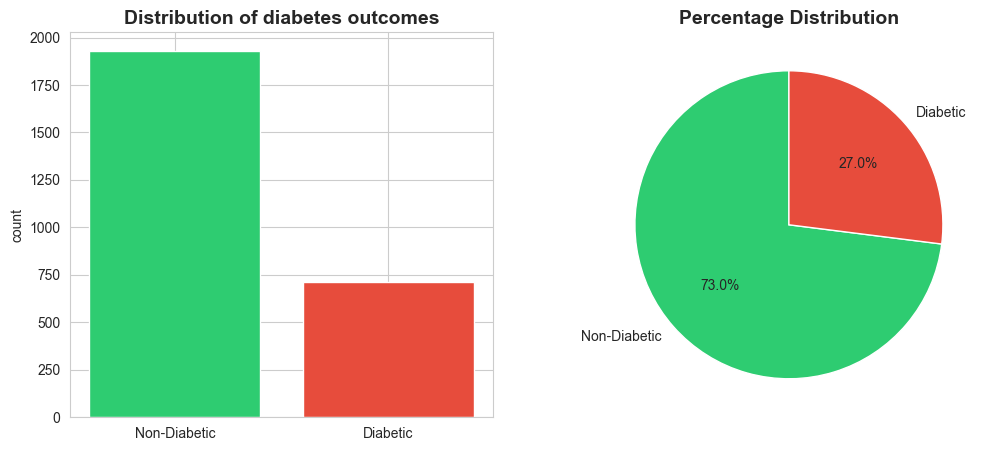

In [75]:
# Visualizing the class distribution
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
outcome_counts = final_df['Outcome'].value_counts()
plt.bar(['Non-Diabetic', 'Diabetic'], outcome_counts.values, color=['#2ecc71','#e74c3c'])
plt.title('Distribution of diabetes outcomes', fontsize=14, fontweight='bold')
plt.ylabel('count')

plt.subplot(1,2,2)
plt.pie(outcome_counts.values, labels=['Non-Diabetic', 'Diabetic'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
plt.title('Percentage Distribution', fontsize=14, fontweight='bold')
plt.show()

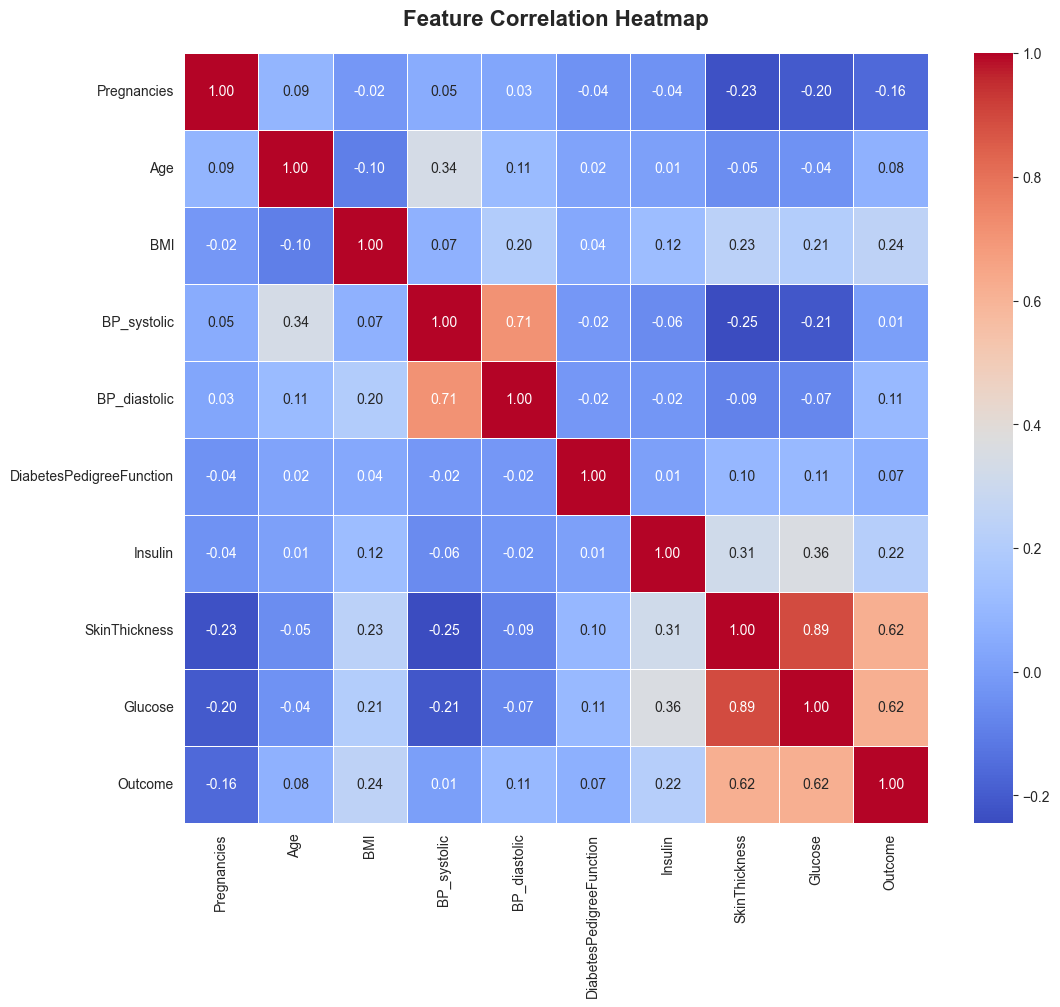

In [76]:
# Visualizing the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(final_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20, fontweight='bold')
plt.show()

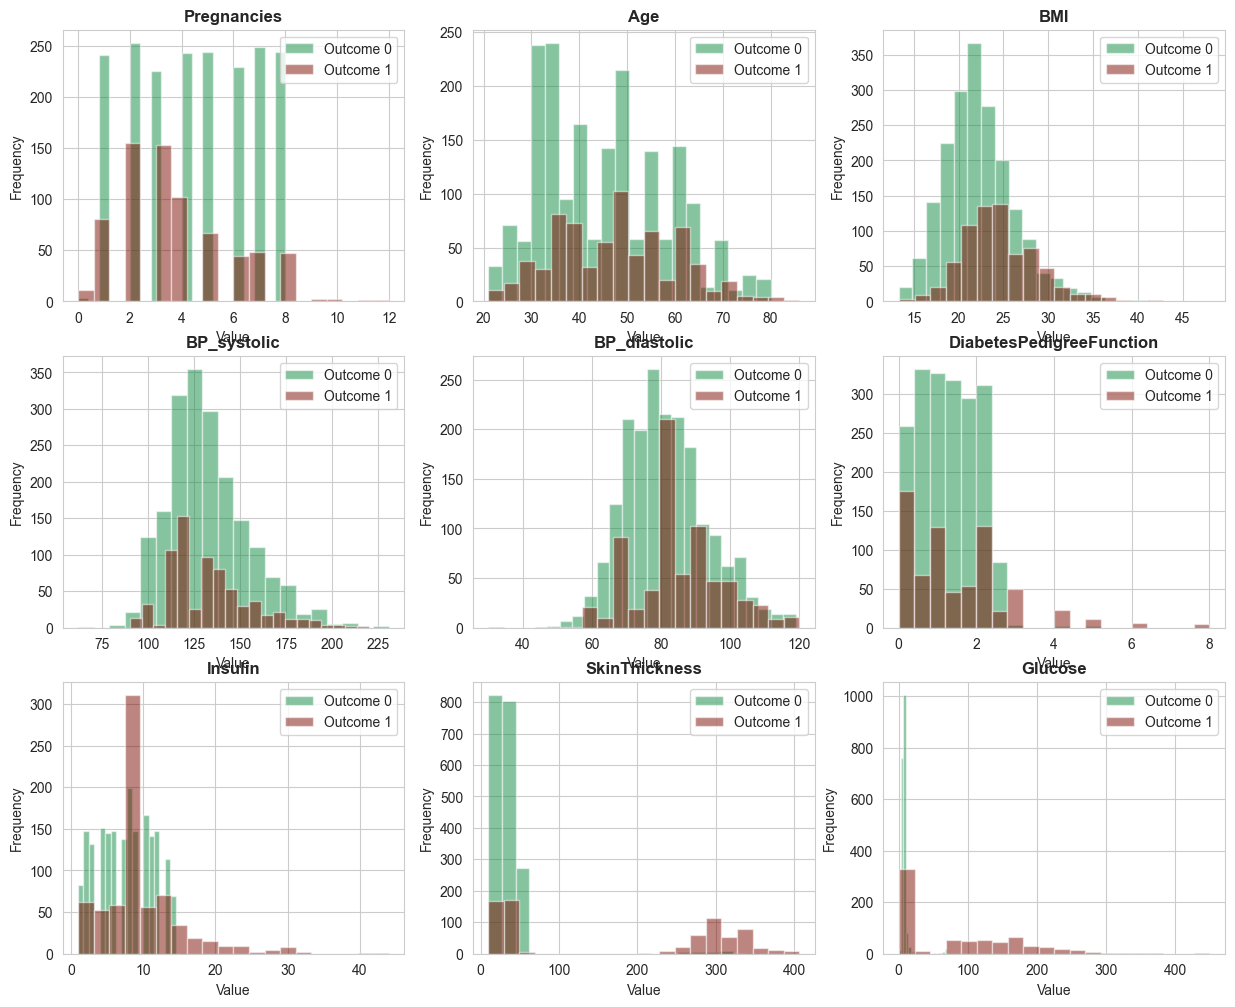

In [77]:
# Visualizing the distribution of features for diabetic vs non-diabetic outcomes
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
features = final_df.columns[:-1]

for idx, feature in enumerate(features):
    row, col = idx // 3, idx % 3
    for outcome in [0,1]:  
        data = final_df[final_df['Outcome'] == outcome][feature]
        axes[row, col].hist(data, alpha=0.5, label=f'Outcome {outcome}', bins=20, 
                            color=["#0f8a42", "#7a0c00"][outcome])
        axes[row, col].set_title(feature, fontsize=12, fontweight='bold')
        axes[row, col].set_xlabel('Value')
        axes[row, col].set_ylabel('Frequency')
        axes[row, col].legend()
plt.show()

In [78]:
# Preparing the data for modeling
X = final_df.drop('Outcome', axis=1)
y = final_df['Outcome']

print(X)
print(y)

      Pregnancies  Age        BMI  BP_systolic  BP_diastolic  \
0               2   25  16.790000          111            73   
1               2   37  23.822169           90            60   
2               8   52  24.340000          152           100   
3               7   40  31.430000          141            79   
4               1   40  22.060000          173           107   
...           ...  ...        ...          ...           ...   
2640            3   35  25.410000          140            90   
2641            4   36  20.700000          128            83   
2642            1   60  15.550000          170            92   
2643            5   30  20.710000          127            74   
2644            6   65  20.610000          114            71   

      DiabetesPedigreeFunction  Insulin  SkinThickness  Glucose  
0                     2.157546       11             17        6  
1                     1.000000        8            356      100  
2                     0.682393   

In [79]:
# Scaling the features and standardizing the data to improve model performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-9.93475619e-01, -1.58087717e+00, -1.47694332e+00, ...,
         6.81184041e-01, -5.46556974e-01, -4.14102655e-01],
       [-9.93475619e-01, -6.68733173e-01,  2.22833688e-01, ...,
        -1.37630315e-03,  2.79099678e+00,  1.25521237e+00],
       [ 1.62423284e+00,  4.71446829e-01,  3.48000911e-01, ...,
         4.53663926e-01, -3.49651147e-01, -2.54274620e-01],
       ...,
       [-1.42976036e+00,  1.07954283e+00, -1.77666926e+00, ...,
         1.36374438e+00, -2.31507652e-01, -3.96343984e-01],
       [ 3.15378613e-01, -1.20081717e+00, -5.29422609e-01, ...,
        -1.37630315e-03, -5.36711682e-01, -4.14102655e-01],
       [ 7.51663357e-01,  1.45960283e+00, -5.53594055e-01, ...,
         9.08704156e-01, -6.05628721e-01, -4.14102655e-01]],
      shape=(2645, 9))

In [80]:
# Splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=25)
print(X.shape, x_train.shape, x_test.shape)

(2645, 9) (1851, 9) (794, 9)


__Support Vector Machine(SVM)__

In [81]:
# Training the Support Vector Machine (SVM) model
classifier = svm.SVC(kernel='linear', random_state=32, class_weight='balanced', probability=True)
classifier.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [82]:
x_train_pred = classifier.predict(x_train)
training_accuracy = accuracy_score(x_train_pred,y_train)
training_accuracy

0.8676391139924365

In [83]:
# Testing the model
x_test_pred = classifier.predict(x_test)
testing_accuracy_svm = accuracy_score(x_test_pred,y_test)
testing_accuracy_svm

# Transform test data
X_test_scaled = scaler.transform(x_test)

In [84]:
# Evaluating SVM model using precision, recall, and F1-score
precision = precision_score(y_test, x_test_pred)
recall = recall_score(y_test, x_test_pred)
f1 = f1_score(y_test, x_test_pred)

print(f"Precision of SVM: {precision:.2f}")
print(f"Recall of SVM: {recall:.2f}")
print(f"F1-Score of SVM: {f1:.2f}")

Precision of SVM: 0.74
Recall of SVM: 0.68
F1-Score of SVM: 0.71


In [85]:
# Predictions from SVM
y_scores = classifier.decision_function(X_test_scaled)

# Hinge loss calculation
svm_loss = hinge_loss(y_test, y_scores)

print("SVM Hinge Loss:", svm_loss)

SVM Hinge Loss: 1.6066336416424163


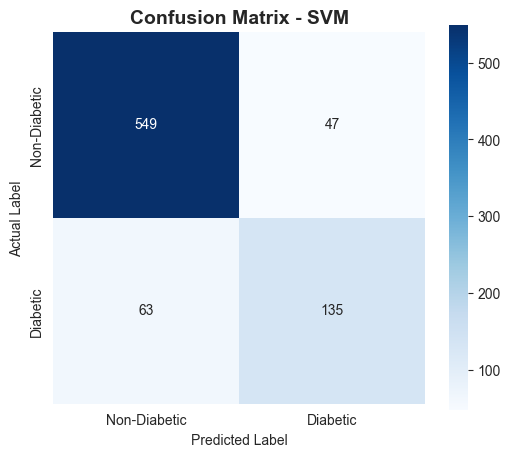

In [86]:
# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, x_test_pred)
cm_svm

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', square=True, 
            xticklabels=['Non-Diabetic', 'Diabetic'], 
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()


**Random Forest Model**

In [87]:
# Training the Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10, 
    random_state=32, 
    class_weight='balanced', 
    min_samples_split=5, 
    min_samples_leaf=2)
rf_classifier.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [88]:
x_train_pred_rf = rf_classifier.predict(x_train)
training_accuracy_rf = accuracy_score(y_train, x_train_pred_rf)
training_accuracy_rf

0.9697460831982712

In [89]:
# Testing the Random Forest model
x_test_pred_rf = rf_classifier.predict(x_test)
testing_accuracy_rf = accuracy_score(y_test, x_test_pred_rf)
testing_accuracy_rf

0.8904282115869018

In [90]:
#Evaluating the Random Forest model
precision_rf = precision_score(y_test, x_test_pred_rf)
recall_rf = recall_score(y_test, x_test_pred_rf)
f1_rf = f1_score(y_test, x_test_pred_rf)
print(f"Precision of Random Forest: {precision_rf:.2f}")
print(f"Recall of Random Forest: {recall_rf:.2f}")
print(f"F1-Score of Random Forest: {f1_rf:.2f}")

Precision of Random Forest: 0.82
Recall of Random Forest: 0.72
F1-Score of Random Forest: 0.77


In [91]:
# Probabilities
y_prob = rf_classifier.predict_proba(X_test_scaled)

# Log loss calculation
rf_loss = log_loss(y_test, y_prob)

print("Random Forest Log Loss:", rf_loss)

Random Forest Log Loss: 0.5716000553718092


In [92]:
cm_rf = confusion_matrix(y_test, x_test_pred_rf)
cm_rf

array([[565,  31],
       [ 56, 142]])

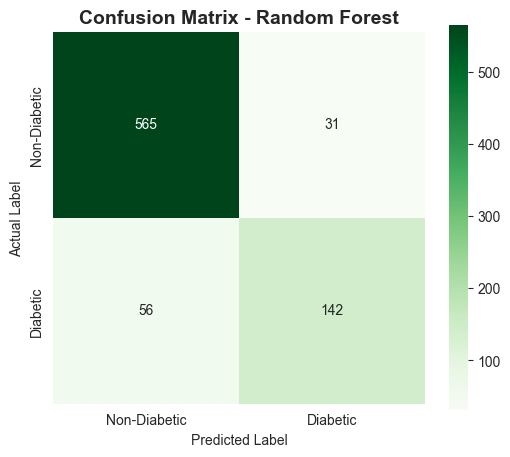

In [93]:
# Visualizing the confusion matrix for Random Forest
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

**Logistic Regression**

In [94]:
# Training the Logistic Regression model
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
lr_classifier = LogisticRegression(random_state=32, class_weight='balanced', max_iter=100)
lr_classifier.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",32
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [95]:
x_train_pred_lr = lr_classifier.predict(x_train_scaled)
training_accuracy_lr = accuracy_score(y_train, x_train_pred_lr)
training_accuracy_lr

0.8535926526202053

In [96]:
# Testing the Logistic Regression model
x_test_pred_lr = lr_classifier.predict(x_test)
testing_accuracy_lr = accuracy_score(y_test, x_test_pred_lr)
testing_accuracy_lr

0.8299748110831234

In [97]:
#Evaluating the Logistic Regression model
precision_lr = precision_score(y_test, x_test_pred_lr)
recall_lr = recall_score(y_test, x_test_pred_lr)
f1_lr = f1_score(y_test, x_test_pred_lr)
print(f"Precision of Logistic Regression: {precision_lr:.2f}")
print(f"Recall of Logistic Regression: {recall_lr:.2f}")
print(f"F1-Score of Logistic Regression: {f1_lr:.2f}")

Precision of Logistic Regression: 0.65
Recall of Logistic Regression: 0.70
F1-Score of Logistic Regression: 0.67


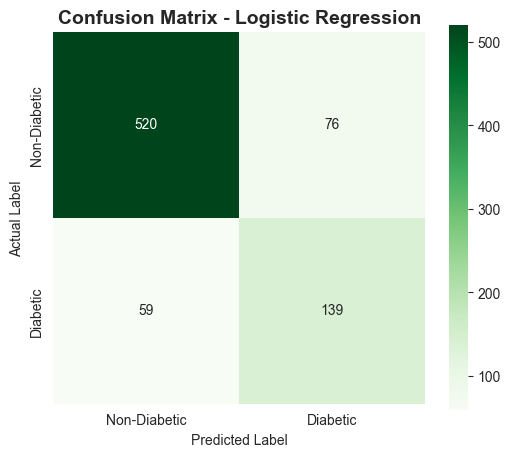

In [98]:
# Visualizing the confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, x_test_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [99]:
# Probability Prediction
y_prob = lr_classifier.predict_proba(X_test_scaled)
# Calculate Log Loss
lr_loss = log_loss(y_test, y_prob)
print("Logistic Regression Log Loss:", lr_loss)

Logistic Regression Log Loss: 1.9315448018360981


In [100]:
# Comparing the accuracies of the three models
print("SVM Accuracy:", testing_accuracy_svm)
print("Random Forest Accuracy:", testing_accuracy_rf)
print("Logistic Regression Accuracy:", testing_accuracy_lr)

if testing_accuracy_rf > testing_accuracy_svm and testing_accuracy_rf > testing_accuracy_lr:
    print("Random Forest performs better.")
elif testing_accuracy_lr > testing_accuracy_svm and testing_accuracy_lr > testing_accuracy_rf:
    print("Logistic Regression performs better.")
else:
    print("SVM performs better.")


SVM Accuracy: 0.8614609571788413
Random Forest Accuracy: 0.8904282115869018
Logistic Regression Accuracy: 0.8299748110831234
Random Forest performs better.


In [101]:
#Comparison based on loss values of SVM, Random Forest and Logistic Regression
if rf_loss < svm_loss and rf_loss < lr_loss:
    print("Random Forest is more suitable for diabetes risk prediction due to its lower loss value.")
elif lr_loss < svm_loss and lr_loss < rf_loss:
    print("Logistic Regression is more suitable for diabetes risk prediction due to its lower loss value.")
else:
    print("SVM is more suitable for diabetes risk prediction due to its lower loss value.")

Random Forest is more suitable for diabetes risk prediction due to its lower loss value.


In [102]:
import joblib

joblib.dump(rf_classifier, 'diabetes_model.pkl') # pyright: ignore[reportUndefinedVariable]
joblib.dump(scaler, 'scaler_svm.pkl') # pyright: ignore[reportUndefinedVariable]
#joblib.dump(lr_classifier, 'diabetes_model_lr.pkl') # pyright: ignore[reportUndefinedVariable]

['scaler_svm.pkl']

In [103]:
# Make a prediction for a new data point
input_data =(1, 21, 22.5, 110, 70, 0.1, 13, 25, 35)
input_num_array = np.array(input_data).reshape(1, -1)

input_data_scaled = scaler.transform(input_num_array)
prediction = rf_classifier.predict(input_data_scaled)

if prediction[0] == 1:
    print("The person is likely to have diabetes.")
else:
    print("The person is unlikely to have diabetes.")


The person is likely to have diabetes.
